In [53]:
# ============================================
# 보충 EDA ② - 골목·전통시장 매출 결정 요인 확인
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 추정매출 로드
매출_파일들 = glob.glob('data/extracted/서울시_상권분석서비스(추정매출+영역)/서울시_상권분석서비스(추정매출-상권)_*.csv')
매출_리스트 = []
for 파일 in 매출_파일들:
    if '2025' in 파일:
        continue
    df = pd.read_csv(파일, encoding='cp949', low_memory=False)
    매출_리스트.append(df)
sales = pd.concat(매출_리스트, ignore_index=True)

# 영역상권 로드
area = pd.read_csv(
    'data/extracted/서울시_상권분석서비스(추정매출+영역)/서울시 상권분석서비스(영역-상권).csv',
    encoding='cp949'
)

# 길단위인구 로드
floating = pd.read_csv(
    'data/extracted/서울시 상권분석서비스(길단위인구-상권)/서울시 상권분석서비스(길단위인구-상권).csv',
    encoding='cp949'
)

# 직장인구 로드
df_직장 = pd.read_csv(
    'data/extracted/서울시 상권분석서비스(직장인구-상권)/서울시 상권분석서비스(직장인구-상권).csv',
    encoding='cp949'
)

# 상주인구 로드
df_상주 = pd.read_csv(
    'data/extracted/서울시 상권분석서비스(상주인구-상권)/서울시 상권분석서비스(상주인구-상권).csv',
    encoding='cp949'
)

print(f'추정매출: {sales.shape}')
print(f'영역상권: {area.shape}')
print(f'유동인구: {floating.shape}')
print(f'직장인구: {df_직장.shape}')
print(f'상주인구: {df_상주.shape}')

추정매출: (434199, 55)
영역상권: (1650, 11)
유동인구: (46184, 27)
직장인구: (45840, 26)
상주인구: (40812, 29)


In [54]:
# ============================================
# 데이터 병합
# ============================================

# 분석 기간 필터링 (2019Q1~2024Q4)
sales = sales[sales['기준_년분기_코드'] < 20250]

# 상권 단위 매출 집계
sales_agg = sales.groupby(
    ['기준_년분기_코드', '상권_코드', '상권_구분_코드_명']
).agg(
    당월_매출=('당월_매출_금액', 'sum'),
    당월_건수=('당월_매출_건수', 'sum')
).reset_index()

sales_agg['객단가'] = sales_agg['당월_매출'] / sales_agg['당월_건수'].replace(0, np.nan)

# 영역상권 병합 (좌표)
sales_agg = sales_agg.merge(
    area[['상권_코드', '자치구_코드_명', '엑스좌표_값', '와이좌표_값']],
    on='상권_코드', how='left'
)

# 유동인구 병합
sales_agg = sales_agg.merge(
    floating[['기준_년분기_코드', '상권_코드', '총_유동인구_수']],
    on=['기준_년분기_코드', '상권_코드'], how='left'
)

# 직장인구 병합
sales_agg = sales_agg.merge(
    df_직장[['기준_년분기_코드', '상권_코드', '총_직장_인구_수']],
    on=['기준_년분기_코드', '상권_코드'], how='left'
)

# 상주인구 병합
sales_agg = sales_agg.merge(
    df_상주[['기준_년분기_코드', '상권_코드', '총_상주인구_수']],
    on=['기준_년분기_코드', '상권_코드'], how='left'
)

print(f'병합 완료: {sales_agg.shape}')
print(f'상권 유형: {sales_agg["상권_구분_코드_명"].unique()}')
print(f'결측치 확인:')
print(sales_agg[['총_유동인구_수', '총_직장_인구_수', '총_상주인구_수']].isna().sum())

병합 완료: (31382, 12)
상권 유형: <StringArray>
['관광특구', '골목상권', '발달상권', '전통시장']
Length: 4, dtype: str
결측치 확인:
총_유동인구_수      11
총_직장_인구_수    173
총_상주인구_수     312
dtype: int64


In [55]:
# ============================================
# 골목·전통시장 한정 필터링
# ============================================

골목_전통 = sales_agg[
    sales_agg['상권_구분_코드_명'].isin(['골목상권', '전통시장'])
].copy()

print(f'골목+전통시장 데이터: {골목_전통.shape}')
print(골목_전통['상권_구분_코드_명'].value_counts())

골목+전통시장 데이터: (26282, 12)
상권_구분_코드_명
골목상권    20697
전통시장     5585
Name: count, dtype: int64


In [56]:
# ============================================
# 핵심 변수별 매출 상관관계
# 목적: 유동인구 vs 직장인구 vs 상주인구 중 뭐가 매출을 결정하는지
# ============================================

# 비교할 변수 3개 정의
변수들 = ['총_유동인구_수', '총_직장_인구_수', '총_상주인구_수']

print(' 골목상권 + 전통시장 — 매출 결정 요인 상관계수')
print('=' * 50)

# 골목상권, 전통시장 각각 반복
for 유형 in ['골목상권', '전통시장']:
    
    # 해당 유형만 필터링
    sub = 골목_전통[골목_전통['상권_구분_코드_명'] == 유형]
    
    print(f'\n {유형}')  
    
    # 변수별 매출 상관계수 계산
    for 변수 in 변수들:
        # 결측치 제거 후 상관계수 계산 (0행:매출, 1열:변수)
        corr = sub[['당월_매출', 변수]].dropna().corr().iloc[0, 1]
        print(f'  {변수:<15} × 매출 상관계수: {corr:.3f}')

 골목상권 + 전통시장 — 매출 결정 요인 상관계수

 골목상권
  총_유동인구_수        × 매출 상관계수: 0.443
  총_직장_인구_수       × 매출 상관계수: 0.414
  총_상주인구_수        × 매출 상관계수: 0.442

 전통시장
  총_유동인구_수        × 매출 상관계수: 0.296
  총_직장_인구_수       × 매출 상관계수: 0.305
  총_상주인구_수        × 매출 상관계수: 0.105


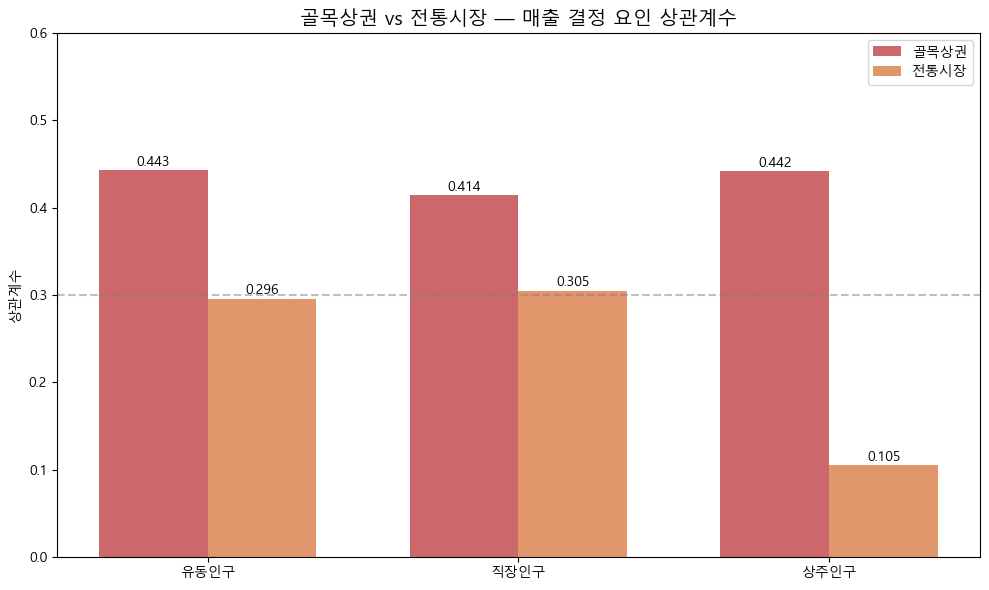

In [57]:
# ============================================
# 매출 결정 요인 상관계수 비교 막대그래프
# ============================================

# 상관계수 데이터 정리
변수_라벨 = ['유동인구', '직장인구', '상주인구']
골목_corr = [0.443, 0.414, 0.442]
전통_corr = [0.296, 0.305, 0.105]

x = np.arange(len(변수_라벨))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

# 막대 그래프
bars1 = ax.bar(x - width/2, 골목_corr, width, label='골목상권', color='#C44E52', alpha=0.85)
bars2 = ax.bar(x + width/2, 전통_corr, width, label='전통시장', color='#DD8452', alpha=0.85)

# 수치 표시
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', fontsize=10)

ax.set_title('골목상권 vs 전통시장 — 매출 결정 요인 상관계수', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(변수_라벨)
ax.set_ylabel('상관계수')
ax.set_ylim(0, 0.6)
ax.legend()
ax.axhline(y=0.3, color='gray', linestyle='--', alpha=0.5, label='기준선 0.3')

plt.tight_layout()
plt.show()

In [58]:
# 점포 합본 로드
점포_파일들 = glob.glob('data/extracted/상권분석서비스(점포_상권)/*.csv')
점포_리스트 = []
for 파일 in 점포_파일들:
    df = pd.read_csv(파일, encoding='cp949', low_memory=False)
    점포_리스트.append(df)
df_점포 = pd.concat(점포_리스트, ignore_index=True)

# 분석 기간 필터링
df_점포 = df_점포[df_점포['기준_년분기_코드'] < 20250]

print(f'점포 데이터: {df_점포.shape}')
print(df_점포.columns.tolist())

점포 데이터: (1831925, 14)
['기준_년분기_코드', '상권_구분_코드', '상권_구분_코드_명', '상권_코드', '상권_코드_명', '서비스_업종_코드', '서비스_업종_코드_명', '점포_수', '유사_업종_점포_수', '개업_율', '개업_점포_수', '폐업_률', '폐업_점포_수', '프랜차이즈_점포_수']


In [59]:
# ============================================
# 상권 유형별 업종 다양성 비교
# 목적: 업종구성이 매출을 결정하는지 확인
# ============================================

# 상권 유형별 평균 업종수 계산
# nunique = 고유한 업종 수 (다양성 지표)
업종다양성 = df_점포.groupby(
    ['상권_코드', '상권_구분_코드_명']
)['서비스_업종_코드'].nunique().reset_index()

업종다양성.columns = ['상권_코드', '상권_구분_코드_명', '업종수']

# 상권 유형별 평균 업종수
평균_업종수 = 업종다양성.groupby('상권_구분_코드_명')['업종수'].mean().round(1)
print('상권 유형별 평균 업종수')
print(평균_업종수.sort_values(ascending=False))

상권 유형별 평균 업종수
상권_구분_코드_명
관광특구    89.8
발달상권    80.0
골목상권    53.6
전통시장    44.0
Name: 업종수, dtype: float64


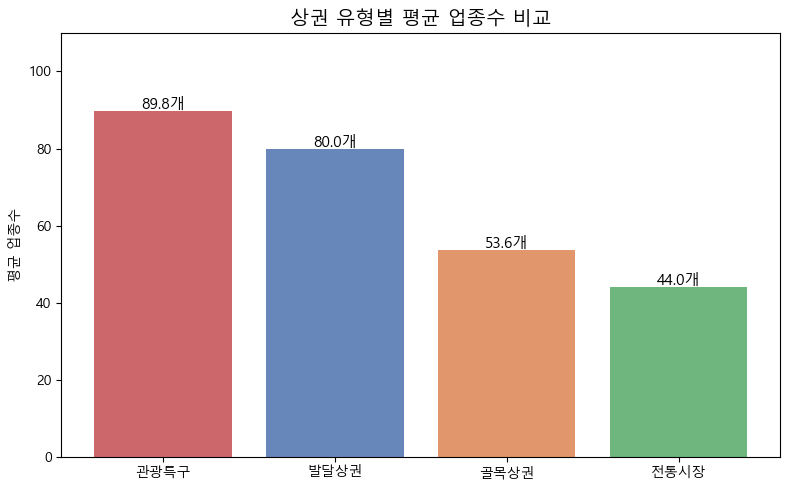

In [60]:
# ============================================
# 상권 유형별 평균 업종수 막대그래프
# ============================================

fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#C44E52', '#4C72B0', '#DD8452', '#55A868']
유형순서 = ['관광특구', '발달상권', '골목상권', '전통시장']
값 = [평균_업종수[유형] for 유형 in 유형순서]

bars = ax.bar(유형순서, 값, color=colors, alpha=0.85)

# 수치 표시
for bar, val in zip(bars, 값):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{val}개', ha='center', fontsize=11)

ax.set_title('상권 유형별 평균 업종수 비교', fontsize=14)
ax.set_ylabel('평균 업종수')
ax.set_ylim(0, 110)

plt.tight_layout()
plt.show()

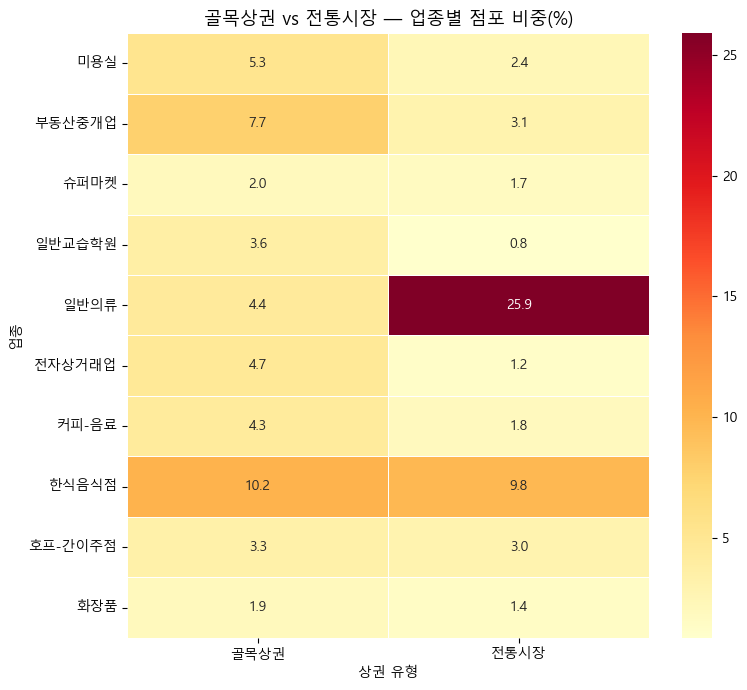

In [61]:
# ============================================
# 골목·전통시장 TOP 10 업종 매출 비중 비교
# 목적: 업종구성이 상권 유형별로 어떻게 다른지
# ============================================

# 골목·전통시장 필터링
골목_전통_점포 = df_점포[
    df_점포['상권_구분_코드_명'].isin(['골목상권', '전통시장'])
]

# 상권 유형별 업종별 점포수 합산
업종_비중 = 골목_전통_점포.groupby(
    ['상권_구분_코드_명', '서비스_업종_코드_명']
)['점포_수'].sum().reset_index()

# 전체 점포수 대비 비중 계산
총점포 = 업종_비중.groupby('상권_구분_코드_명')['점포_수'].transform('sum')
업종_비중['비중'] = (업종_비중['점포_수'] / 총점포 * 100).round(2)

# 골목상권 TOP 10 업종
골목_top10 = (
    업종_비중[업종_비중['상권_구분_코드_명'] == '골목상권']
    .nlargest(10, '비중')['서비스_업종_코드_명']
    .tolist()
)

# TOP 10 업종만 피벗
pivot = 업종_비중[
    업종_비중['서비스_업종_코드_명'].isin(골목_top10)
].pivot(
    index='서비스_업종_코드_명',
    columns='상권_구분_코드_명',
    values='비중'
).fillna(0)

# 히트맵
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    pivot,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax
)
ax.set_title('골목상권 vs 전통시장 — 업종별 점포 비중(%)', fontsize=13)
ax.set_xlabel('상권 유형')
ax.set_ylabel('업종')
plt.tight_layout()
plt.show()

In [62]:
pip install geopandas --break-system-packages

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [63]:
# ============================================
# 역세권 분석
# 목적: 지하철역 500m 이내 상권 = 역세권으로 분류
# ============================================

import geopandas as gpd
from shapely.geometry import Point

# 지하철역 좌표 로드
df_역 = pd.read_csv(
    '../data/12_외부데이터/서울교통공사_1_8호선 역사 좌표(위경도) 정보_20250814.csv',
    encoding='cp949'
)

print(f'지하철역 데이터: {df_역.shape}')
print(df_역.head(3))

지하철역 데이터: (276, 8)
   연번  호선  고유역번호(외부역코드)  역명         위도          경도        작성일자       작성기준일
0   1   1           150  서울  37.553150  126.972533  1974-02-28  2025-08-14
1   2   1           151  시청  37.563590  126.975407  1974-08-15  2025-08-14
2   3   1           152  종각  37.570203  126.983116  1974-08-15  2025-08-14


In [64]:
# ============================================
# GeoDataFrame 변환 및 역세권 분류
# 좌표계: WGS84(경위도) → UTM-K(미터 단위)로 변환해야 거리 계산 가능
# ============================================

# 지하철역 GeoDataFrame 생성
gdf_역 = gpd.GeoDataFrame(
    df_역,
    geometry=gpd.points_from_xy(df_역['경도'], df_역['위도']),
    crs='EPSG:4326'  # WGS84 좌표계
)

# 상권 GeoDataFrame 생성 (영역상권 파일의 좌표 사용)
gdf_상권 = gpd.GeoDataFrame(
    sales_agg.drop_duplicates('상권_코드'),
    geometry=gpd.points_from_xy(
        sales_agg.drop_duplicates('상권_코드')['엑스좌표_값'],
        sales_agg.drop_duplicates('상권_코드')['와이좌표_값']
    ),
    crs='EPSG:4326'
)

# 미터 단위로 좌표계 변환 (거리 계산용)
gdf_역_m = gdf_역.to_crs('EPSG:5179')      # UTM-K
gdf_상권_m = gdf_상권.to_crs('EPSG:5179')  # UTM-K

print(f'지하철역: {len(gdf_역_m)}개')
print(f'상권: {len(gdf_상권_m)}개')

지하철역: 276개
상권: 1603개


In [65]:
# 좌표 확인
print('상권 좌표 샘플:')
print(gdf_상권_m.geometry[:3])
print()
print('지하철역 좌표 샘플:')
print(gdf_역_m.geometry[:3])
print()
# print('역 좌표 배열 샘플:')
# print(역_coords[:3])

상권 좌표 샘플:
0    POINT (Infinity Infinity)
1    POINT (Infinity Infinity)
2    POINT (Infinity Infinity)
Name: geometry, dtype: geometry

지하철역 좌표 샘플:
0    POINT (953410.048 1950553.661)
1    POINT (953670.369 1951710.506)
2    POINT (954355.232 1952440.413)
Name: geometry, dtype: geometry



In [66]:
# 영역상권 좌표 확인
print(area[['상권_코드', '엑스좌표_값', '와이좌표_값']].head(5))
print()
print('결측치:')
print(area[['엑스좌표_값', '와이좌표_값']].isna().sum())
print()
print('좌표 범위:')
print(area[['엑스좌표_값', '와이좌표_값']].describe())

     상권_코드  엑스좌표_값  와이좌표_값
0  3110008  197093  453418
1  3110009  196991  455057
2  3110010  197064  456643
3  3110017  198581  453781
4  3110018  198883  453690

결측치:
엑스좌표_값    0
와이좌표_값    0
dtype: int64

좌표 범위:
              엑스좌표_값         와이좌표_값
count    1650.000000    1650.000000
mean   198981.845455  449875.451515
std      7280.720618    5590.503325
min    182509.000000  437249.000000
25%    192815.250000  445178.500000
50%    200096.000000  449849.500000
75%    204366.250000  453563.500000
max    215352.000000  465573.000000


In [67]:
# ============================================
# 좌표계 수정 - 영역상권은 TM중부(EPSG:2097)
# ============================================

# 상권 GeoDataFrame 다시 생성 (올바른 좌표계로)
상권_unique = sales_agg.drop_duplicates('상권_코드').merge(
    area[['상권_코드', '엑스좌표_값', '와이좌표_값', '상권_구분_코드_명']],
    on='상권_코드', how='left'
)

gdf_상권 = gpd.GeoDataFrame(
    상권_unique,
    geometry=gpd.points_from_xy(
        상권_unique['엑스좌표_값_y'],
        상권_unique['와이좌표_값_y']
    ),
    crs='EPSG:2097'
)

# UTM-K로 변환
gdf_상권_m = gdf_상권.to_crs('EPSG:5179')

print('상권 좌표 샘플:')
print(gdf_상권_m.geometry[:3])

상권 좌표 샘플:
0    POINT (955139.171 1948757.885)
1    POINT (954056.217 1952065.444)
2    POINT (956656.114 1952413.438)
Name: geometry, dtype: geometry


In [68]:
# ============================================
# 역세권 여부 분류 (500m 이내)
# ============================================

# 역 좌표 배열로 변환
역_coords = np.array([(geom.x, geom.y) for geom in gdf_역_m.geometry])

def 최근접역_거리(상권_point):
    if 상권_point is None or 상권_point.is_empty:
        return np.nan
    sx, sy = 상권_point.x, 상권_point.y
    거리들 = np.sqrt((역_coords[:, 0] - sx)**2 + (역_coords[:, 1] - sy)**2)
    return 거리들.min()

gdf_상권_m['최근접역_거리_m'] = gdf_상권_m.geometry.apply(최근접역_거리)

# 역세권 분류
gdf_상권_m['역세권'] = gdf_상권_m['최근접역_거리_m'] <= 500

print('완료!')
print(gdf_상권_m['역세권'].value_counts())
print(f'\n평균 최근접역 거리: {gdf_상권_m["최근접역_거리_m"].mean():.0f}m')

완료!
역세권
False    857
True     746
Name: count, dtype: int64

평균 최근접역 거리: 707m


In [69]:
# 역 좌표랑 상권 좌표 범위 비교
print('역 좌표 범위:')
print(f'X: {역_coords[:,0].min():.0f} ~ {역_coords[:,0].max():.0f}')
print(f'Y: {역_coords[:,1].min():.0f} ~ {역_coords[:,1].max():.0f}')
print()
print('상권 좌표 범위:')
상권_coords = [(geom.x, geom.y) for geom in gdf_상권_m.geometry]
상권_x = [c[0] for c in 상권_coords]
상권_y = [c[1] for c in 상권_coords]
print(f'X: {min(상권_x):.0f} ~ {max(상권_x):.0f}')
print(f'Y: {min(상권_y):.0f} ~ {max(상권_y):.0f}')

역 좌표 범위:
X: 938290 ~ 975567
Y: 1937256 ~ 1966826

상권 좌표 범위:
X: 938176 ~ 971005
Y: 1937742 ~ 1965990


In [70]:
print(gdf_상권_m.geometry[:3])

0    POINT (955139.171 1948757.885)
1    POINT (954056.217 1952065.444)
2    POINT (956656.114 1952413.438)
Name: geometry, dtype: geometry


In [71]:
print(sales_agg.columns.tolist())

['기준_년분기_코드', '상권_코드', '상권_구분_코드_명', '당월_매출', '당월_건수', '객단가', '자치구_코드_명', '엑스좌표_값', '와이좌표_값', '총_유동인구_수', '총_직장_인구_수', '총_상주인구_수']


In [72]:
# 상권 좌표 다시 생성
상권_unique2 = sales_agg.drop_duplicates('상권_코드').copy()

gdf_상권 = gpd.GeoDataFrame(
    상권_unique2,
    geometry=gpd.points_from_xy(
        상권_unique2['엑스좌표_값'],
        상권_unique2['와이좌표_값']
    ),
    crs='EPSG:2097'
)

# UTM-K로 변환
gdf_상권_m = gdf_상권.to_crs('EPSG:5179')

print('상권 좌표 샘플:')
print(gdf_상권_m.geometry[:3])

상권 좌표 샘플:
0    POINT (955139.171 1948757.885)
1    POINT (954056.217 1952065.444)
2    POINT (956656.114 1952413.438)
Name: geometry, dtype: geometry


In [73]:
# 역 좌표 배열로 변환
역_coords = np.array([(geom.x, geom.y) for geom in gdf_역_m.geometry])

def 최근접역_거리(상권_point):
    if 상권_point is None or 상권_point.is_empty:
        return np.nan
    sx, sy = 상권_point.x, 상권_point.y
    거리들 = np.sqrt((역_coords[:, 0] - sx)**2 + (역_coords[:, 1] - sy)**2)
    return 거리들.min()

gdf_상권_m['최근접역_거리_m'] = gdf_상권_m.geometry.apply(최근접역_거리)

# 역세권 분류
gdf_상권_m['역세권'] = gdf_상권_m['최근접역_거리_m'] <= 500

print('완료!')
print(gdf_상권_m['역세권'].value_counts())
print(f'\n평균 최근접역 거리: {gdf_상권_m["최근접역_거리_m"].mean():.0f}m')

완료!
역세권
False    857
True     746
Name: count, dtype: int64

평균 최근접역 거리: 707m


In [74]:
# ============================================
# 역세권 vs 비역세권 매출 비교
# ============================================

# 역세권 여부를 sales_agg에 병합
sales_agg_역세권 = sales_agg.merge(
    gdf_상권_m[['상권_코드', '역세권', '최근접역_거리_m']],
    on='상권_코드',
    how='left'
)

# 골목·전통시장 한정
골목_전통_역세권 = sales_agg_역세권[
    sales_agg_역세권['상권_구분_코드_명'].isin(['골목상권', '전통시장'])
]

# 역세권 여부별 평균 매출 비교
print(' 골목·전통시장 역세권 vs 비역세권 매출 비교')
print('=' * 50)

for 유형 in ['골목상권', '전통시장']:
    sub = 골목_전통_역세권[골목_전통_역세권['상권_구분_코드_명'] == 유형]
    역세권_매출 = sub[sub['역세권'] == True]['객단가'].median()
    비역세권_매출 = sub[sub['역세권'] == False]['객단가'].median()
    print(f'\n {유형}')
    print(f'  역세권 평균 객단가:    {역세권_매출:,.0f}원')
    print(f'  비역세권 평균 객단가:  {비역세권_매출:,.0f}원')
    print(f'  차이: {역세권_매출 - 비역세권_매출:,.0f}원')

 골목·전통시장 역세권 vs 비역세권 매출 비교

 골목상권
  역세권 평균 객단가:    23,443원
  비역세권 평균 객단가:  21,565원
  차이: 1,878원

 전통시장
  역세권 평균 객단가:    25,397원
  비역세권 평균 객단가:  22,610원
  차이: 2,787원


In [75]:
pip install folium --break-system-packages

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [76]:
import os

# 폴더 없으면 자동 생성
os.makedirs('../outputs', exist_ok=True)

In [77]:
# ============================================
# Folium 지도 시각화 - 역세권 vs 비역세권
# ============================================

import folium

gdf_상권_wgs = gdf_상권_m.to_crs('EPSG:4326')
gdf_역_wgs = gdf_역_m.to_crs('EPSG:4326')

# 서울 중심 좌표로 지도 생성
m = folium.Map(location=[37.5665, 126.9780], zoom_start=11)

# 비역세권 상권 (회색)
for _, row in gdf_상권_wgs[gdf_상권_m['역세권'] == False].iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=4,
        color='gray',
        fill=True,
        fill_opacity=0.4,
        popup=f"{row['상권_구분_코드_명']} | 비역세권"
    ).add_to(m)

# 역세권 상권 (파란색)
for _, row in gdf_상권_wgs[gdf_상권_m['역세권'] == True].iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=4,
        color='blue',
        fill=True,
        fill_opacity=0.6,
        popup=f"{row['상권_구분_코드_명']} | 역세권"
    ).add_to(m)

# 지하철역 (빨간색)
for _, row in gdf_역_wgs.iterrows():
    folium.Marker(
        location=[row.geometry.y, row.geometry.x],
        popup=row['역명'],
        icon=folium.Icon(color='red', icon='train', prefix='fa')
    ).add_to(m)

# HTML로 저장
m.save('../outputs/역세권_지도.html')

In [78]:
pip install contextily --break-system-packages

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


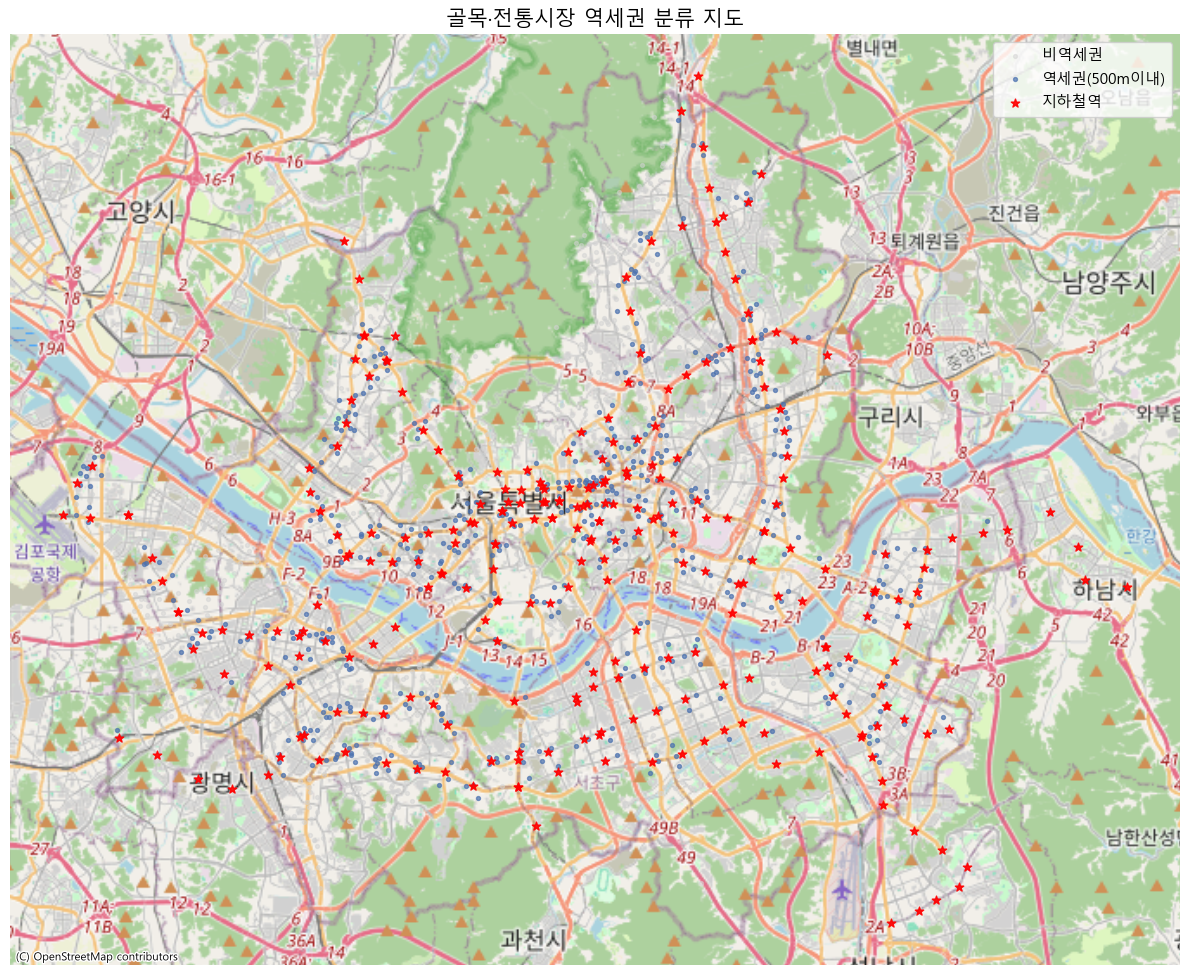

저장 완료!


In [79]:
# ============================================
# 역세권 지도 시각화 
# ============================================

import contextily as ctx

fig, ax = plt.subplots(figsize=(12, 12))

# Web Mercator로 변환 
gdf_상권_web = gdf_상권_m.to_crs('EPSG:3857')
gdf_역_web = gdf_역_m.to_crs('EPSG:3857')

# 골목·전통시장만 필터링
골목전통_web = gdf_상권_web[
    gdf_상권_web['상권_구분_코드_명'].isin(['골목상권', '전통시장'])
]

# 비역세권 (회색)
골목전통_web[골목전통_web['역세권'] == False].plot(
    ax=ax, color='lightgray', markersize=8, alpha=0.5, label='비역세권'
)

# 역세권 (파란색)
골목전통_web[골목전통_web['역세권'] == True].plot(
    ax=ax, color='#4C72B0', markersize=8, alpha=0.7, label='역세권(500m이내)'
)

# 지하철역 (빨간 별)
gdf_역_web.plot(
    ax=ax, color='red', markersize=40, marker='*', label='지하철역', alpha=0.9
)

# 배경지도 추가
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_title('골목·전통시장 역세권 분류 지도', fontsize=15)
ax.legend(fontsize=11)
ax.set_axis_off()

plt.tight_layout()
plt.savefig('../outputs/역세권_지도.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료!')

통계

In [80]:
from scipy import stats
import numpy as np

In [81]:
for 유형 in ['골목상권', '전통시장']:
    sub = 골목_전통_역세권[골목_전통_역세권['상권_구분_코드_명'] == 유형]
    역 = sub[sub['역세권']==True]['객단가'].dropna()
    비역 = sub[sub['역세권']==False]['객단가'].dropna()
    
    stat, p = stats.mannwhitneyu(역, 비역, alternative='two-sided')
    print(f"{유형} | U={stat:.0f}, p={p:.4f}")

골목상권 | U=54546056, p=0.0000
전통시장 | U=4614121, p=0.0000


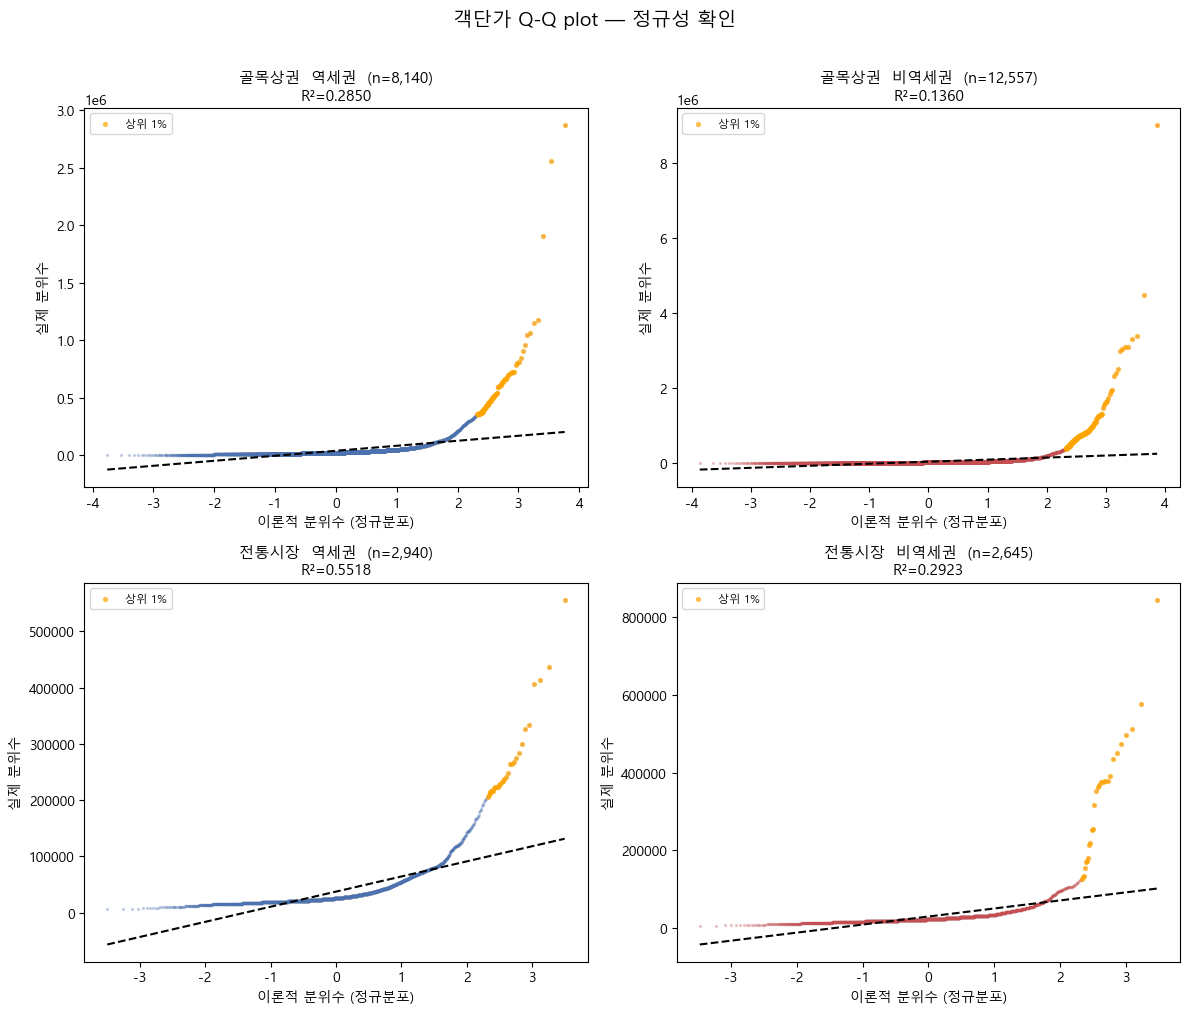

In [82]:
# ============================================
# 객단가 Q-Q plot — 4개 그룹
# ============================================
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('객단가 Q-Q plot — 정규성 확인', fontsize=14, y=1.01)

설정 = [
    ('골목상권', '역세권',   '#4C72B0', axes[0][0]),
    ('골목상권', '비역세권', '#C44E52', axes[0][1]),
    ('전통시장', '역세권',   '#4C72B0', axes[1][0]),
    ('전통시장', '비역세권', '#C44E52', axes[1][1]),
]

for 유형, 구분, color, ax in 설정:
    sub  = 골목_전통_역세권[골목_전통_역세권['상권_구분_코드_명'] == 유형]
    is_역 = 구분 == '역세권'
    data = sub[sub['역세권'] == is_역]['객단가'].dropna()

    (osm, osr), (slope, intercept, r) = stats.probplot(data, dist='norm')

    ax.scatter(osm, osr, s=2, alpha=0.25, color=color)
    ax.plot(osm, slope * np.array(osm) + intercept,
            color='black', lw=1.5, linestyle='--')

    # 벗어나는 구간 강조 (상위 1%)
    q99_idx = int(len(osm) * 0.99)
    ax.scatter(osm[q99_idx:], osr[q99_idx:],
               s=8, alpha=0.6, color='orange', zorder=5, label='상위 1%')

    ax.set_title(f'{유형}  {구분}  (n={len(data):,})\nR²={r**2:.4f}', fontsize=11)
    ax.set_xlabel('이론적 분위수 (정규분포)')
    ax.set_ylabel('실제 분위수')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [83]:
# ============================================
# Mann-Whitney U 검정 — 역세권 vs 비역세권 객단가
# ============================================
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── 효과크기 계산 함수 (rank-biserial r) ──────────────────
def rank_biserial_r(u_stat, n1, n2):
    """Mann-Whitney U → 효과크기 r (0=없음, 0.1=소, 0.3=중, 0.5=대)"""
    return 1 - (2 * u_stat) / (n1 * n2)

print('=' * 60)
print(' Mann-Whitney U 검정 — 역세권 vs 비역세권 객단가')
print('=' * 60)

results = {}

for 유형 in ['골목상권', '전통시장']:
    sub = 골목_전통_역세권[골목_전통_역세권['상권_구분_코드_명'] == 유형]
    
    역 = sub[sub['역세권'] == True]['객단가'].dropna()
    비역 = sub[sub['역세권'] == False]['객단가'].dropna()

    # Mann-Whitney U 검정
    u_stat, p_val = stats.mannwhitneyu(역, 비역, alternative='two-sided')
    
    # 효과크기
    r = rank_biserial_r(u_stat, len(역), len(비역))
    
    # 효과크기 해석
    if abs(r) >= 0.5:
        효과크기_해석 = '대(large)'
    elif abs(r) >= 0.3:
        효과크기_해석 = '중(medium)'
    elif abs(r) >= 0.1:
        효과크기_해석 = '소(small)'
    else:
        효과크기_해석 = '무시 가능'

    # 유의성 해석
    유의성 = '★ 유의 (p<0.05)' if p_val < 0.05 else '비유의 (p≥0.05)'

    results[유형] = {
        'n_역': len(역), 'n_비역': len(비역),
        'median_역': 역.median(), 'median_비역': 비역.median(),
        'u_stat': u_stat, 'p_val': p_val,
        'r': r, '효과크기_해석': 효과크기_해석, '유의성': 유의성
    }

    print(f'\n▶ {유형}')
    print(f'  표본 수         : 역세권 n={len(역):,} / 비역세권 n={len(비역):,}')
    print(f'  중앙값          : 역세권 {역.median():,.0f}원 / 비역세권 {비역.median():,.0f}원')
    print(f'  U 통계량        : {u_stat:,.0f}')
    print(f'  p-value         : {p_val:.4f}  →  {유의성}')
    print(f'  효과크기 r      : {r:.3f}  →  {효과크기_해석}')

print('\n' + '=' * 60)
print(' 해석 기준: |r| ≥ 0.5=대 / ≥ 0.3=중 / ≥ 0.1=소')
print('=' * 60)

 Mann-Whitney U 검정 — 역세권 vs 비역세권 객단가

▶ 골목상권
  표본 수         : 역세권 n=8,140 / 비역세권 n=12,557
  중앙값          : 역세권 23,443원 / 비역세권 21,565원
  U 통계량        : 54,546,056
  p-value         : 0.0000  →  ★ 유의 (p<0.05)
  효과크기 r      : -0.067  →  무시 가능

▶ 전통시장
  표본 수         : 역세권 n=2,940 / 비역세권 n=2,645
  중앙값          : 역세권 25,397원 / 비역세권 22,610원
  U 통계량        : 4,614,121
  p-value         : 0.0000  →  ★ 유의 (p<0.05)
  효과크기 r      : -0.187  →  소(small)

 해석 기준: |r| ≥ 0.5=대 / ≥ 0.3=중 / ≥ 0.1=소


<!-- n1 = len(역)
n2 = len(비역)

# Z-score 계산
from scipy.stats import norm
z = (stat - (n1*n2/2)) / np.sqrt(n1*n2*(n1+n2+1)/12)

# effect size
r = abs(z) / np.sqrt(n1 + n2)

print(f"effect size r: {r:.3f}") -->

“골목상권과 전통시장 모두에서 역세권 여부에 따른 객단가 차이는 통계적으로 유의하였다(Mann-Whitney U test, p < 0.001). 그러나 효과 크기(r = 0.161)는 작은 수준으로 나타나, 역세권 여부는 매출에 일부 영향을 미치지만 주요 결정 요인으로 보기에는 한계가 있다.”

5060대 매출 상관관계 분석

In [84]:
# df_상주['5060_비중'] = (
#     df_상주['연령대_50_상주인구_수'] + df_상주['연령대_60_이상_상주인구_수']
# ) / df_상주['총_상주인구_수']

In [85]:
# 골목_전통_5060 = sales_agg[
#     sales_agg['상권_구분_코드_명'].isin(['골목상권', '전통시장'])
# ].merge(
#     df_상주[['기준_년분기_코드', '상권_코드', '총_상주인구_수', '5060_비중']],
#     on=['기준_년분기_코드', '상권_코드'],
#     how='left'
# )

In [86]:
# ============================================
# 5060 인구수 계산 (상주·직장·유동 전부)
# ============================================

df_상주['5060_상주_수'] = (
    df_상주['연령대_50_상주인구_수'] + df_상주['연령대_60_이상_상주인구_수']
)

df_직장['5060_직장_수'] = (
    df_직장['연령대_50_직장_인구_수'] + df_직장['연령대_60_이상_직장_인구_수']
)

floating['5060_유동_수'] = (
    floating['연령대_50_유동인구_수'] + floating['연령대_60_이상_유동인구_수']
)


In [87]:
# ============================================
# 매출과 병합
# ============================================
골목_전통_5060 = sales_agg[
    sales_agg['상권_구분_코드_명'].isin(['골목상권', '전통시장'])
].merge(
    df_상주[['기준_년분기_코드', '상권_코드', '5060_상주_수']],
    on=['기준_년분기_코드', '상권_코드'], how='left'
).merge(
    df_직장[['기준_년분기_코드', '상권_코드', '5060_직장_수']],
    on=['기준_년분기_코드', '상권_코드'], how='left'
).merge(
    floating[['기준_년분기_코드', '상권_코드', '5060_유동_수']],
    on=['기준_년분기_코드', '상권_코드'], how='left'
)

In [88]:
# ============================================
# 피어슨 상관계수 비교
# ============================================
변수_목록 = {
    '총 상주인구': '총_상주인구_수',
    '5060 상주_수': '5060_상주_수',
    '총 직장인구': '총_직장_인구_수',
    '5060 직장_수': '5060_직장_수',
    '총 유동인구': '총_유동인구_수',
    '5060 유동_수': '5060_유동_수',
}

print('전체 vs 5060 인구 — 매출 피어슨 상관계수 비교')
print('=' * 55)

for 유형 in ['전통시장', '골목상권']:
    sub = 골목_전통_5060[골목_전통_5060['상권_구분_코드_명'] == 유형]
    print(f'\n [{유형}]')
    for 라벨, 컬럼 in 변수_목록.items():
        corr = sub[['당월_매출', 컬럼]].dropna().corr().iloc[0, 1]
        print(f'  {라벨:<15} × 매출: {corr:.3f}')

전체 vs 5060 인구 — 매출 피어슨 상관계수 비교

 [전통시장]
  총 상주인구          × 매출: 0.105
  5060 상주_수       × 매출: 0.081
  총 직장인구          × 매출: 0.305
  5060 직장_수       × 매출: 0.300
  총 유동인구          × 매출: 0.296
  5060 유동_수       × 매출: 0.309

 [골목상권]
  총 상주인구          × 매출: 0.442
  5060 상주_수       × 매출: 0.417
  총 직장인구          × 매출: 0.414
  5060 직장_수       × 매출: 0.434
  총 유동인구          × 매출: 0.443
  5060 유동_수       × 매출: 0.415


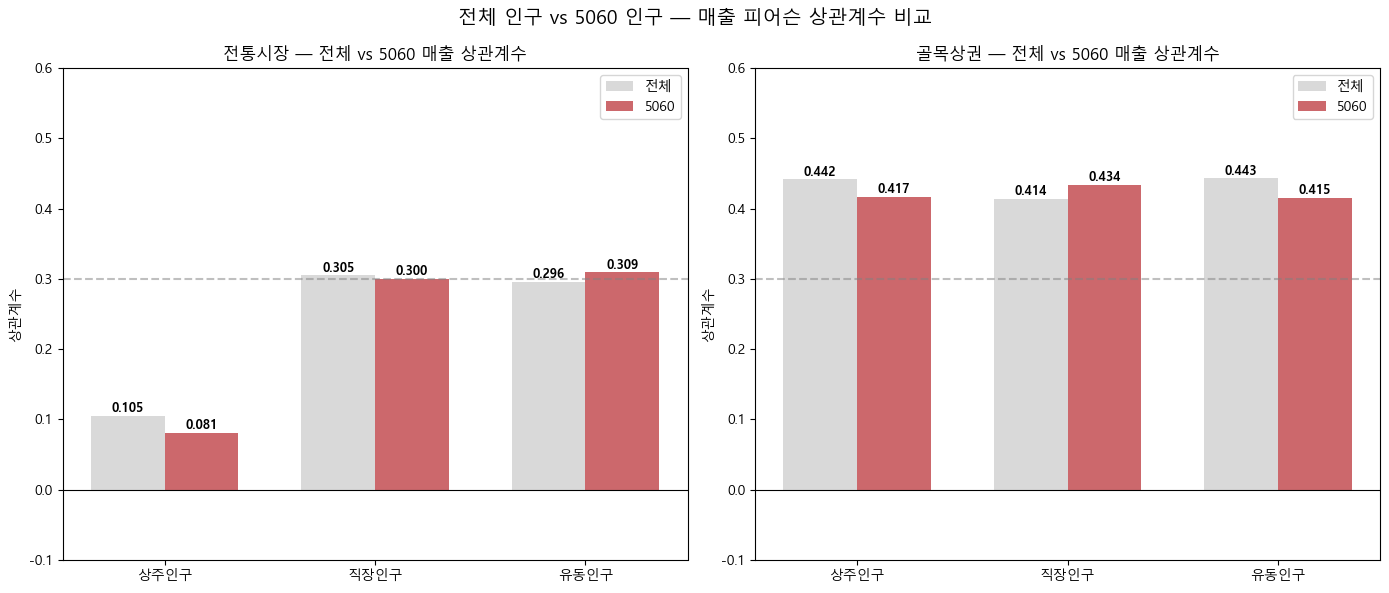

In [90]:
# ============================================
# 시각화
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

x = np.arange(3)
width = 0.35
라벨_그룹 = ['상주인구', '직장인구', '유동인구']

for i, 유형 in enumerate(['전통시장', '골목상권']):
    sub = 골목_전통_5060[골목_전통_5060['상권_구분_코드_명'] == 유형]

    전체_corr = [
        sub[['당월_매출', '총_상주인구_수']].dropna().corr().iloc[0, 1],
        sub[['당월_매출', '총_직장_인구_수']].dropna().corr().iloc[0, 1],
        sub[['당월_매출', '총_유동인구_수']].dropna().corr().iloc[0, 1],
    ]
    오060_corr = [
        sub[['당월_매출', '5060_상주_수']].dropna().corr().iloc[0, 1],
        sub[['당월_매출', '5060_직장_수']].dropna().corr().iloc[0, 1],
        sub[['당월_매출', '5060_유동_수']].dropna().corr().iloc[0, 1],
    ]

    ax = axes[i]
    bars1 = ax.bar(x - width/2, 전체_corr, width, label='전체', color='lightgray', alpha=0.85)
    bars2 = ax.bar(x + width/2, 오060_corr, width, label='5060', color='#C44E52', alpha=0.85)

    for bar in bars1 + bars2:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2,
                h + 0.005 if h >= 0 else h - 0.02,
                f'{h:.3f}', ha='center', fontsize=9, fontweight='bold')

    ax.set_title(f'{유형} — 전체 vs 5060 매출 상관계수', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(라벨_그룹)
    ax.set_ylabel('상관계수')
    ax.set_ylim(-0.1, 0.6)
    ax.axhline(y=0, color='black', linewidth=0.8)
    ax.axhline(y=0.3, color='gray', linestyle='--', alpha=0.5)
    ax.legend()

plt.suptitle('전체 인구 vs 5060 인구 — 매출 피어슨 상관계수 비교', fontsize=14)
plt.tight_layout()
plt.show()

역세권 vs 비역세권 객단가 분석

In [91]:
for 유형 in ['골목상권', '전통시장']:
    sub = 골목_전통_역세권[골목_전통_역세권['상권_구분_코드_명'] == 유형]
    역 = sub[sub['역세권'] == True]['객단가'].dropna()
    비역 = sub[sub['역세권'] == False]['객단가'].dropna()
    print(f'[{유형}] 역세권: {len(역)}개, 비역세권: {len(비역)}개')

[골목상권] 역세권: 8140개, 비역세권: 12557개
[전통시장] 역세권: 2940개, 비역세권: 2645개


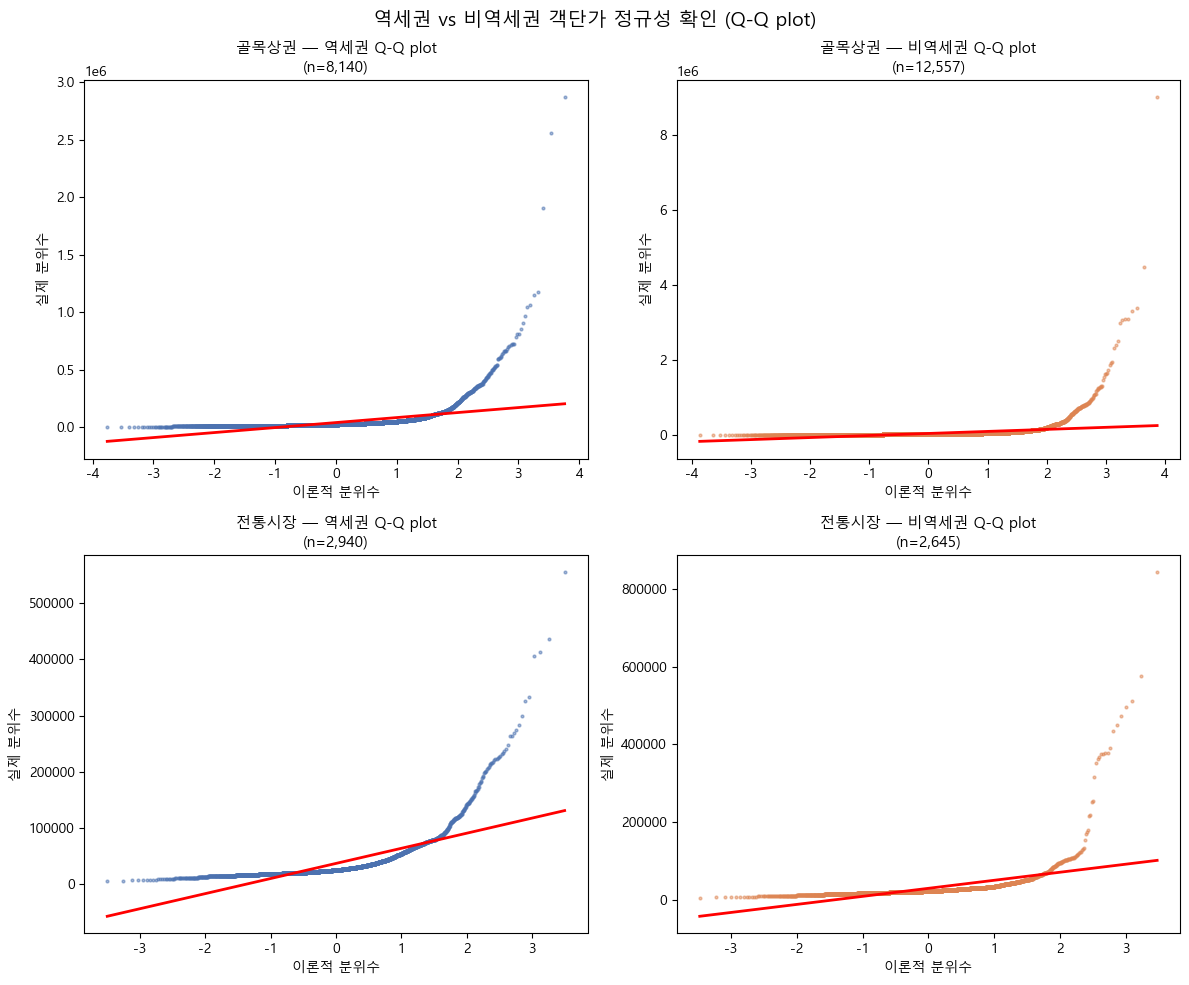

In [93]:
from scipy import stats

# ============================================
# Q-Q plot으로 정규성 확인
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for i, 유형 in enumerate(['골목상권', '전통시장']):
    sub = 골목_전통_역세권[골목_전통_역세권['상권_구분_코드_명'] == 유형]

    for j, (그룹명, 색) in enumerate([('역세권', '#4C72B0'), ('비역세권', '#DD8452')]):
        값 = sub[sub['역세권'] == (그룹명 == '역세권')]['객단가'].dropna()

        ax = axes[i][j]
        stats.probplot(값, dist='norm', plot=ax)

        # 색상 변경
        ax.get_lines()[0].set(color=색, alpha=0.5, markersize=2)
        ax.get_lines()[1].set(color='red', linewidth=2)

        ax.set_title(f'{유형} — {그룹명} Q-Q plot\n(n={len(값):,})', fontsize=11)
        ax.set_xlabel('이론적 분위수')
        ax.set_ylabel('실제 분위수')

plt.suptitle('역세권 vs 비역세권 객단가 정규성 확인 (Q-Q plot)', fontsize=14)
plt.tight_layout()
plt.show()

In [94]:
from scipy.stats import mannwhitneyu

print('역세권 vs 비역세권 객단가 — Mann-Whitney U test')
print('=' * 55)

for 유형 in ['골목상권', '전통시장']:
    sub = 골목_전통_역세권[골목_전통_역세권['상권_구분_코드_명'] == 유형]
    역세권_값 = sub[sub['역세권'] == True]['객단가'].dropna()
    비역세권_값 = sub[sub['역세권'] == False]['객단가'].dropna()

    stat, p = mannwhitneyu(역세권_값, 비역세권_값, alternative='greater')

    역_중앙 = 역세권_값.median()
    비역_중앙 = 비역세권_값.median()
    차이율 = (역_중앙 - 비역_중앙) / 비역_중앙 * 100

    print(f'\n [{유형}]')
    print(f'  역세권 중앙값:    {역_중앙:,.0f}원 (n={len(역세권_값):,})')
    print(f'  비역세권 중앙값:  {비역_중앙:,.0f}원 (n={len(비역세권_값):,})')
    print(f'  차이율:           {차이율:.1f}%')
    print(f'  U통계량:          {stat:,.0f}')
    print(f'  p-value:          {p:.4f}')
    if p < 0.05:
        print(f'  결론: ✅ 유의미한 차이 (p < 0.05)')
    else:
        print(f'  결론: ❌ 유의미한 차이 없음 (p >= 0.05)')

역세권 vs 비역세권 객단가 — Mann-Whitney U test

 [골목상권]
  역세권 중앙값:    23,443원 (n=8,140)
  비역세권 중앙값:  21,565원 (n=12,557)
  차이율:           8.7%
  U통계량:          54,546,056
  p-value:          0.0000
  결론: ✅ 유의미한 차이 (p < 0.05)

 [전통시장]
  역세권 중앙값:    25,397원 (n=2,940)
  비역세권 중앙값:  22,610원 (n=2,645)
  차이율:           12.3%
  U통계량:          4,614,121
  p-value:          0.0000
  결론: ✅ 유의미한 차이 (p < 0.05)


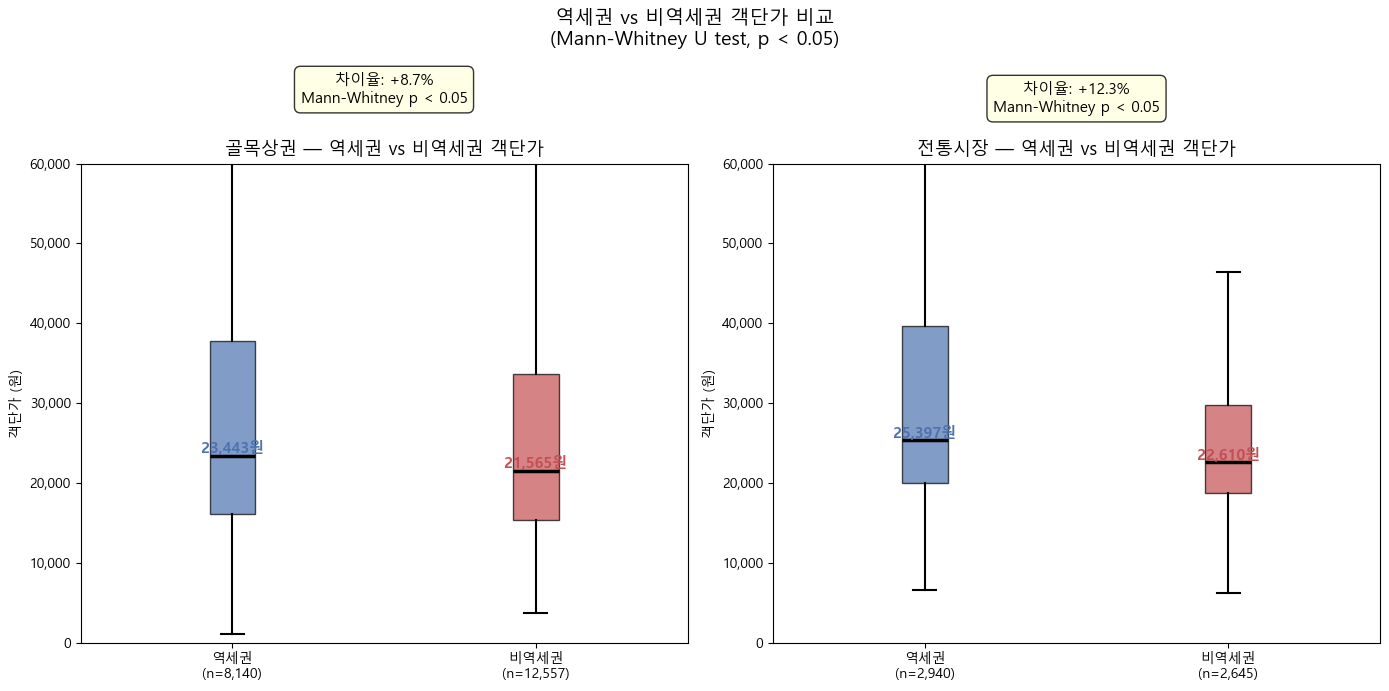

In [97]:
# ============================================
# 역세권 vs 비역세권 객단가 시각화
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

색상_역 = '#4C72B0'
색상_비역 = '#C44E52'

for i, 유형 in enumerate(['골목상권', '전통시장']):
    sub = 골목_전통_역세권[골목_전통_역세권['상권_구분_코드_명'] == 유형]
    역세권_값 = sub[sub['역세권'] == True]['객단가'].dropna()
    비역세권_값 = sub[sub['역세권'] == False]['객단가'].dropna()

    ax = axes[i]

    # 박스플롯
    bp = ax.boxplot(
        [역세권_값, 비역세권_값],
        labels=[f'역세권\n(n={len(역세권_값):,})', f'비역세권\n(n={len(비역세권_값):,})'],
        patch_artist=True,
        boxprops=dict(alpha=0.7),
        medianprops=dict(color='black', linewidth=2.5),
        whiskerprops=dict(linewidth=1.5),
        capprops=dict(linewidth=1.5),
        flierprops=dict(marker='o', markersize=2, alpha=0.3),
        showfliers=False  # 이상치 제거
    )

    # 색상 적용
    bp['boxes'][0].set_facecolor(색상_역)
    bp['boxes'][1].set_facecolor(색상_비역)

    # 중앙값 텍스트 표시
    역_중앙 = 역세권_값.median()
    비역_중앙 = 비역세권_값.median()
    차이율 = (역_중앙 - 비역_중앙) / 비역_중앙 * 100

    ax.text(1, 역_중앙 + 300, f'{역_중앙:,.0f}원',
            ha='center', fontsize=11, fontweight='bold', color=색상_역)
    ax.text(2, 비역_중앙 + 300, f'{비역_중앙:,.0f}원',
            ha='center', fontsize=11, fontweight='bold', color=색상_비역)

    # p-value 및 차이율 표시
    ax.text(1.5, ax.get_ylim()[1] * 0.92,
            f'차이율: +{차이율:.1f}%\nMann-Whitney p < 0.05',
            ha='center', fontsize=11,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.8))

    ax.set_title(f'{유형} — 역세권 vs 비역세권 객단가', fontsize=13)
    ax.set_ylabel('객단가 (원)')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.set_ylim(0, 60000)

plt.suptitle('역세권 vs 비역세권 객단가 비교\n(Mann-Whitney U test, p < 0.05)', fontsize=14)
plt.tight_layout()
plt.show()

골목상권과 전통시장 모두 역세권 상권의 객단가가 비역세권보다 통계적으로 유의미하게 높다. 차이율은 골목상권 8.7%, 전통시장 12.3%로 전통시장에서 역세권 효과가 더 크게 나타난다. 단, 절대 금액 차이는 2,000~3,000원 수준으로 역세권 여부보다 업종 다양성과 배후인구 구조가 매출에 더 강한 영향을 미치는 핵심 요인으로 해석